In [ ]:
"""
@author: Chioma Opara and ChatGPT
Last modified: Fri Feb 8 2026

Plot training loss curves
"""

In [2]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Extract losses from the saved log file
import re
import pandas as pd
import matplotlib.pyplot as plt

log_path = "/content/drive/MyDrive/ImageNet_Project/results/007-DiT-XL-2/log.txt"

steps = []
losses = []

pattern = re.compile(r"\(step=(\d+)\)\s+Train Loss:\s+([0-9.]+)")

with open(log_path, "r", encoding="utf-8") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            steps.append(int(match.group(1)))
            losses.append(float(match.group(2)))

df = pd.DataFrame({
    "step": steps,
    "train_loss": losses
})

print(df.head())
print(df.tail())
print(df["train_loss"].describe())

   step  train_loss
0   100      0.1532
1   200      0.1481
2   300      0.1485
3   400      0.1463
4   500      0.1486
      step  train_loss
206  20700      0.1455
207  20800      0.1455
208  20900      0.1443
209  21000      0.1471
210  21100      0.1442
count    211.000000
mean       0.146730
std        0.001621
min        0.142400
25%        0.145800
50%        0.146700
75%        0.147650
max        0.153200
Name: train_loss, dtype: float64


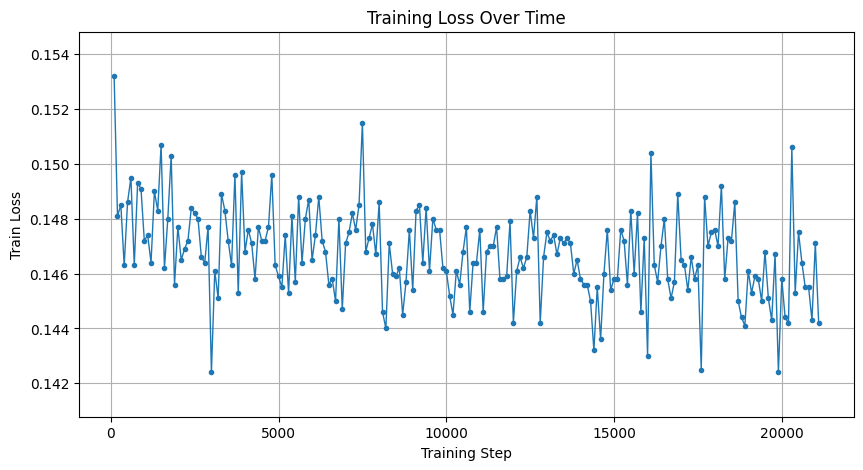

In [6]:
# Plot training loss over time with y-axis zoomed in
y_min = df["train_loss"].min()
y_max = df["train_loss"].max()
padding = (y_max - y_min) * 0.15

plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["train_loss"], marker="o", markersize=3, linewidth=1)
plt.xlabel("Training Step")
plt.ylabel("Train Loss")
plt.title("Training Loss Over Time")
plt.ylim(y_min - padding, y_max + padding)
plt.grid(True)
plt.show()

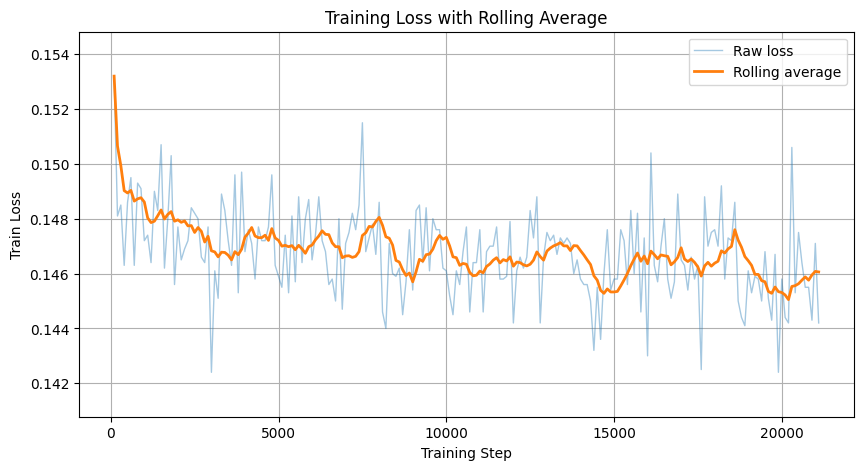

In [5]:
# Plot smoothened training loss curve
df["rolling_loss"] = df["train_loss"].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(10, 5))
plt.plot(df["step"], df["train_loss"], linewidth=1, alpha=0.4, label="Raw loss")
plt.plot(df["step"], df["rolling_loss"], linewidth=2, label="Rolling average")
plt.xlabel("Training Step")
plt.ylabel("Train Loss")
plt.title("Training Loss with Rolling Average")
plt.ylim(y_min - padding, y_max + padding)
plt.legend()
plt.grid(True)
plt.show()